Ground-based observations are significantly impacted by the wavelength-dependent absorption of Earth's atmosphere. This frustration can be exacerbated by the rarity of quick, easy-to-use models for telluric extinction. Although dedicated models may exist for your particular observatory, it is not a guarantee.

In this section, we show how ```specsuite``` can quickly model telluric light loss over visible-NIR wavelengths, and fit for the extinction present in a time-series observation.

<div class="admonition note">
    <p class="admonition-title">Note</p>
    <p>
        To keep the GitHub repository's size relatively small, we have not uploaded enough example data to accurately model telluric extinction. In the setup code block, we generate fake data to use our tools on. These tools have been tested on complete nights of data from KOSMOS and GMOS-N, though!
    </p>
</div>

In [1]:
import chromatic
import numpy as np
import specsuite as ss
import astropy.units as u

# Keeps simulated data fixed
np.random.seed(42)

# In units of Angstroms
data_wavelengths = np.arange(5000, 9000, 20)

# Physical parameters for simulating telluric loss
data_rs_tau0 = 0.5
data_o2_abundance = 200000
data_humidity = 30

# Assumes that observation angle changes linearly
data_times = np.linspace(0, 1, 100)
data_airmass = 1 / np.cos(
    np.radians(
        np.linspace(0, 70, len(data_times))
    )
)

# A PHOENIX spectrum for an M-dwarf star
flux = chromatic.get_phoenix_photons(
    temperature = 3200,
    logg = 5.0,
    metallicity = 0.0,
    wavelength = data_wavelengths * u.AA,
)[1].value

# Simulated telluric losses
fake_throughput = ss.generate_extinction_model(
    wavelengths = data_wavelengths,
    rs_tau0 = data_rs_tau0,
    o2_abundance = data_o2_abundance,
    humidity = data_humidity,
)

# Makes a callable extinction model object
M = ss.ExtinctionModel(
    throughput_model = fake_throughput,
    rs_tau0 = data_rs_tau0,
    o2_abundance = data_o2_abundance,
    humidity = data_humidity,
    loss_constant = 1.0,
    R = 300,
)

# Allows us to multiply this 2D array by our flux array
chromatic_loss = np.array([
    M(X) for X in data_airmass
])

# Generates noisy time-series spectral observation
noise_level = 0.05
data_flux_array = np.array([
    flux * (1 + noise_level * np.random.normal(size=flux.size))
    for _ in data_airmass
])
data_error_array = np.array([
    noise_level * flux for _ in data_airmass
])

# Creates random, achromatic light losses
achromatic_loss = []
for _ in data_times:

    # 30% change for significant cloud cover
    if np.random.uniform(0, 1) > 0.7:
        achromatic_loss.append(
            np.random.uniform(0.2, 1.1)
        )

    # 70% chance for minor cloud cover
    else:
        achromatic_loss.append(
            np.random.uniform(0.95, 1.05)
        )

# Adds random cloud cover losses to simulated data
achromatic_loss = np.array(achromatic_loss)[:, np.newaxis]
data_flux_array *= achromatic_loss * chromatic_loss

We will be using the following packages several times, so might as well import them all here!

In [2]:
import numpy as np
import specsuite as ss
import astropy.units as u
import matplotlib.pyplot as plt

## Basic Usage
### _Generating Telluric Extinction Models_

These models were generated using ```TelFit``` and inferring how the extinction coefficient scales with airmass and molecular abundance. We will use $l_{i}(\lambda)$ to represent this loss rate for some molecule $i$ at some wavelength $\lambda$. Additionally, we include a rough Rayleigh scattering term to handle blue-visible light losses. In its simplest form, ```generate_extinction_model()``` only needs an array of wavelengths (in Angstroms) and the value of the each component's scaling parameter...

(0.0, 1.05)

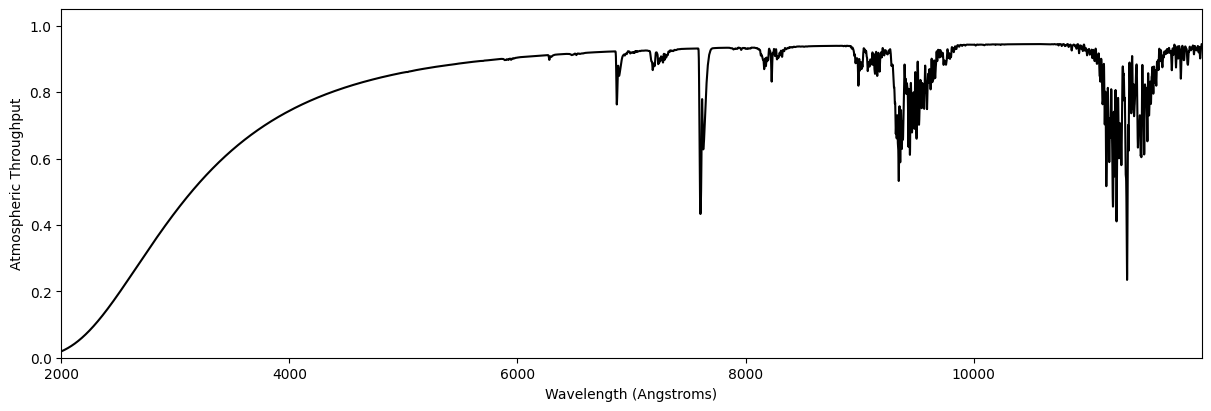

In [3]:
# Wavelengths can be in any astropy units of length
wavelengths = np.arange(2000, 12000, 1) * u.AA

# Generates a simple telluric model at R=2000
throughput = ss.generate_extinction_model(
    wavelengths = wavelengths,
    rs_tau0 = 0.1,            # Rayleigh scattering
    o2_abundance = 100000,    # O2 abundance (ppm)
    humidity = 20,            # Relative humidity (0-100)
    loss_constant = 0.95,     # Achromatic loss factor
)

# Plotting
plt.rcParams["figure.figsize"] = (12, 4)
plt.plot(wavelengths, throughput, color='k')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Atmospheric Throughput')
plt.xlim(np.min(wavelengths.value), np.max(wavelengths.value))
plt.ylim(0, 1.05)

You may want to model telluric absorptions at a different spectral resolution (R). This is easy to do using an optional argument in ```generate_extinction_model()``` (which defaults to R=2000). Be careful, though, as errors in this model become more significant at high resolutions...

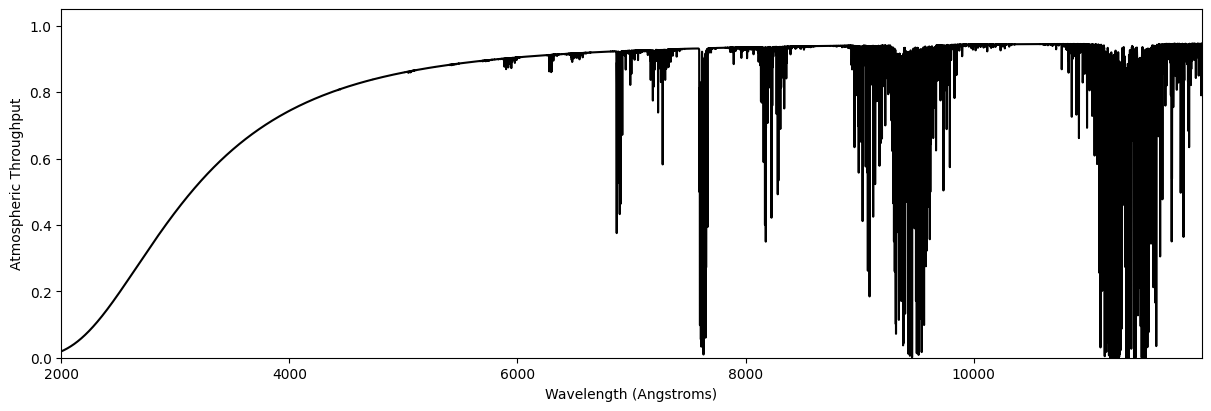

In [4]:
high_R_model = ss.generate_extinction_model(
    wavelengths = wavelengths,
    rs_tau0 = 0.1,            # Rayleigh scattering
    o2_abundance = 100000,    # O2 abundance (ppm)
    humidity = 20,            # Relative humidity (0-100)
    loss_constant = 0.95,     # Achromatic loss factor
    R = 100000,               # Spectral resolution
)

# Plots the high-resolution atmospheric throughput model
plt.rcParams["figure.figsize"] = (12, 4)
plt.plot(wavelengths, high_R_model, color='k')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Atmospheric Throughput')
plt.xlim(np.min(wavelengths.value), np.max(wavelengths.value))
plt.ylim(0, 1.05)
plt.show()

These models are run at an airmass ($\chi$) of 1.0 by default, but this is also easy to change! Let's take a look at the same telluric absorption model at a variety of airmasses...

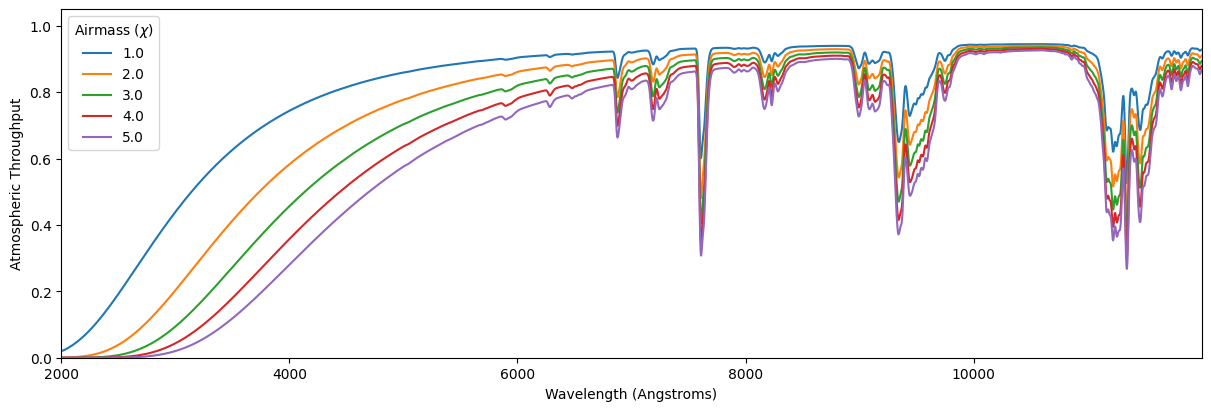

In [5]:
plt.rcParams["figure.figsize"] = (12, 4)

# Varies airmass while holding all other parameters fixed
for airmass in [1.0, 2.0, 3.0, 4.0, 5.0]:

    airmass_model = ss.generate_extinction_model(
        wavelengths = wavelengths,
        rs_tau0 = 0.1,            # Rayleigh scattering
        o2_abundance = 100000,    # O2 abundance (ppm)
        humidity = 20,            # Relative humidity (0-100)
        loss_constant = 0.95,     # Achromatic loss factor
        R = 500,                  # Spectral resolution
        airmass = airmass,        # 1/cos(theta) is reasonable!
    )

    # Plots the high-resolution atmospheric throughput model
    plt.plot(wavelengths, airmass_model, label=airmass)

# Formatting the plot
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Atmospheric Throughput')
plt.legend(title=rf"Airmass ($\chi$)")
plt.xlim(np.min(wavelengths.value), np.max(wavelengths.value))
plt.ylim(0, 1.05)
plt.show()

We can see that airmass deepens all atmospheric absorption features, but not in a linear way! This is because airmass is being applied according to...

\begin{equation}
\log(T(\lambda, t)) = l(\lambda) \cdot \chi(t)
\end{equation}

...where $l(\lambda)$ is the "loss model" including rayleigh scattering and molecular absorption ($\text{O}_2$ and $\text{H}_2\text{O}$). The loss model is not the same as an extinction coefficient ($\tau(\lambda)$), but behaves in an analogous way. For a slightly longer discussion on this point, see ??? below.

<div class="admonition warning">
    <p class="admonition-title">Warning</p>
    <p>
        There are many other factors that could create complex telluric absorption features that are not included in this simple model. We have simplified the above model to incorporate the components most relevant over visible wavelengths, but it is far from exhaustive. If you need a high-resolution that is incredibly accurate, this is likely the wrong tool for your purposes!
    </p>
</div>

### _Fitting Telluric Losses_
If you are taking time-series data, you can often make a decent inference about the atmospheric throughput over the course of your observation. This is commonly done by looking for wavelength-dependent variations in a comparison star's flux as a function of airmass (assuming the comparison star's flux is relatively constant over the course of a single night). Let's look at some synthetic data for this type of observation...

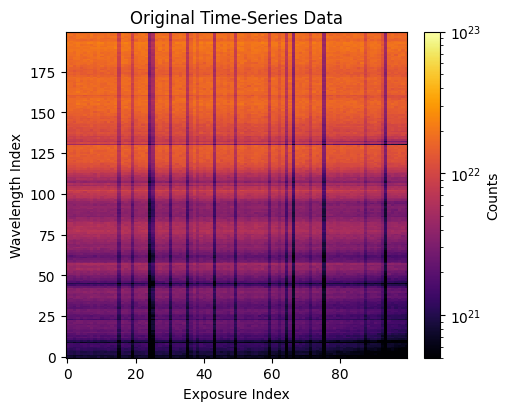

In [6]:
ss.plot_image(
    data_flux_array.T,
    norm = "log",
    title = "Original Time-Series Data",
    xlabel = "Exposure Index",
    ylabel = "Wavelength Index",
    figsize = (5, 4),
    vmin = 5e20,
    vmax = 1e23,
)

The dark vertical bands represent a random, single exposure drop in brightness that seems to impact all wavelengths equally. These are often caused by cloud cover, and the intensity is strongly related to the type and density of the cloud. You may also see that the data gets slightly darker towards the last exposures. In this case, that gradual change is caused by the telescope looking at an increasing amount of the atmosphere. We can model both of these effects using the following function...

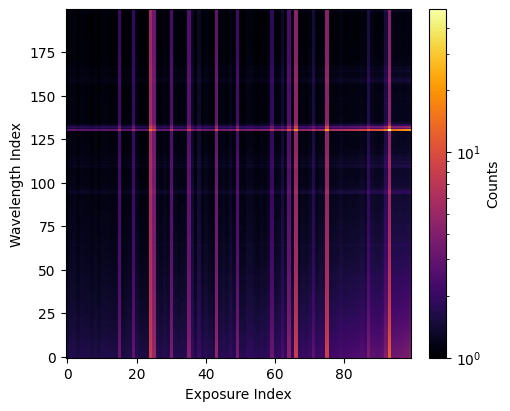

In [7]:
# Estimates multiplicative flux correction factors
correction = ss.estimate_atmospheric_loss(
    wavelengths = data_wavelengths,
    flux = data_flux_array,
    error = data_error_array,
    times = data_times,
    airmass = data_airmass,
)

# Plots the telluric correction factor array
ss.plot_image(
    correction.T,
    norm = "log",
    xlabel = "Exposure Index",
    ylabel = "Wavelength Index",
    figsize = (5, 4),
)

This ```correction``` variable is a 2D array that represents how much we would need to multiply ```data_flux_array``` by to correct for the two atmospheric effects described above. When we do this, we get the following corrected time-series data...

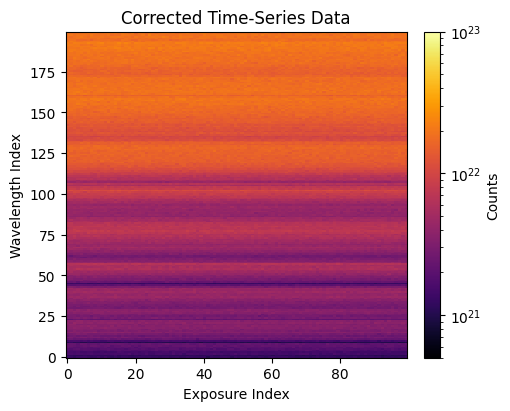

In [8]:
ss.plot_image(
    (data_flux_array * correction).T,
    norm = "log",
    title = "Corrected Time-Series Data",
    xlabel = "Exposure Index",
    ylabel = "Wavelength Index",
    figsize = (5, 4),
    vmin = 5e20,
    vmax = 1e23,
)

Those pesky features appear mostly corrected for! Realistically, your data will likely have contaminants that cannot be explained using the model outlined above. This model should do a decent job eliminating some of these sources, though!

### _Inferring Average Extinction Coefficients_
In case you just want to extract the average extinction coefficients from your data, you can do so using the following function...

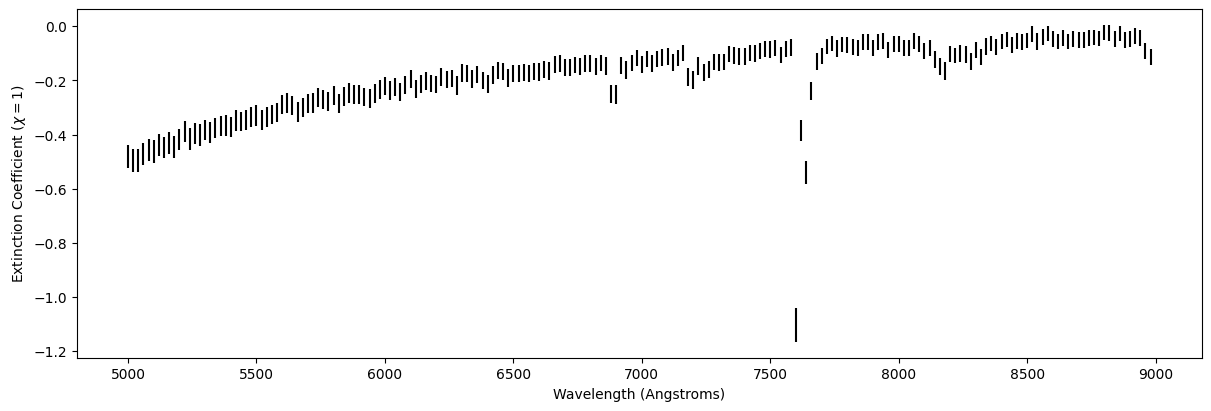

In [9]:
# Estimates extinction coefficients at an airmass of 1.0
taus, taus_error = ss.estimate_extinction_coefficients(
    airmass = data_airmass,
    flux = data_flux_array,
    error = data_error_array,
)

# Plots estimated extinction coefficients
plt.rcParams["figure.figsize"] = (12, 4)
plt.errorbar(
    x = data_wavelengths,
    y = taus,
    yerr = taus_error,
    markersize = 3,
    fmt = "none",
    color='k',
)
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel(rf"Extinction Coefficient ($\chi=1$)")
plt.show()

This represents the average extinction coefficient corresponding to an airmass of 1.0. Converting this into other airmasses is as simple as multiplying the ```taus``` and ```taus_error``` by the new airmass. So, the inferred atmospheric throughput at an airmass of 1.5 is given by...

Text(0, 0.5, 'Atmospheric Throughput')

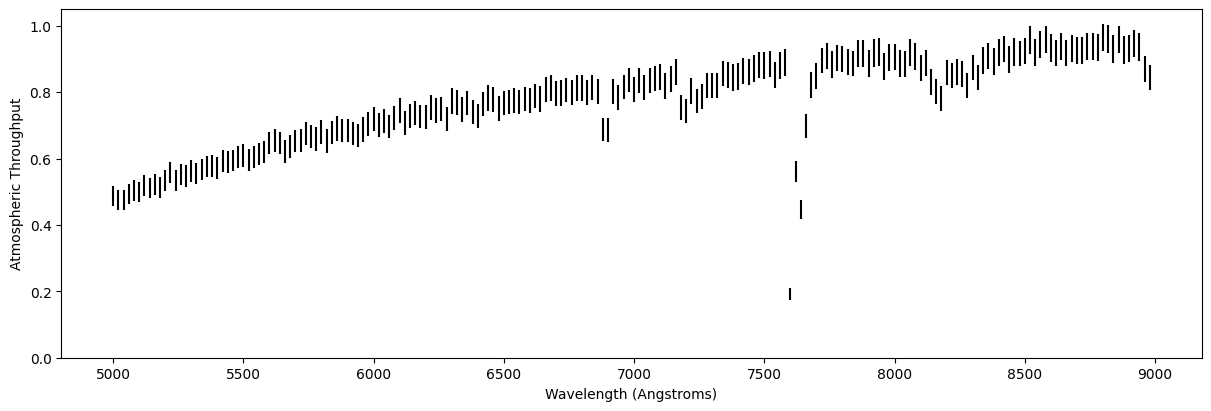

In [10]:
# Error propagation is important here!
taus_new = taus * 1.5
taus_error_new = taus_error * 1.5

# Converts into atmospheric throughput
throughput = np.exp(taus_new)
throughput_error = throughput * taus_error_new

# Plots the estimated atmospheric throughput
plt.errorbar(
    x = data_wavelengths,
    y = throughput,
    yerr = throughput_error,
    markersize = 3,
    fmt = "none",
    color='k',
)
plt.ylim(0, 1.05)
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Atmospheric Throughput")

### _Accessing Telluric Loss Models_
You may wish to see the models ```specsuite``` uses to model atmospheric extinction for your own applications. The easiest way to do this is using the ```_load_extinction_file()``` function...

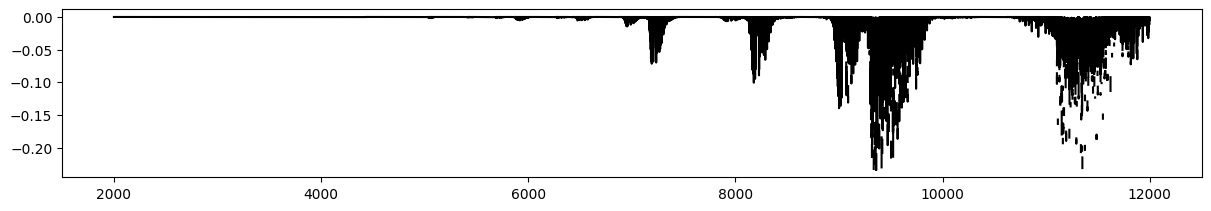

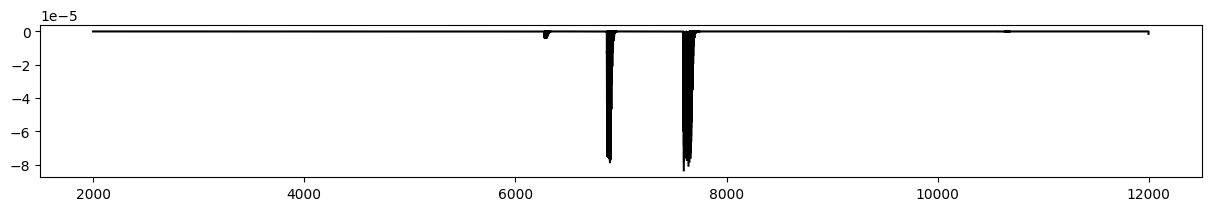

In [11]:
# Wavelengths are in units of Angstroms
model_wavelengths = ss.extraction._load_extinction_file(
    name = "model_wavelengths",
)

# To calculate tau, multiply array by abundance and airmass
o2_model = ss.extraction._load_extinction_file(
    name = "o2_array",
)
humidity_model = ss.extraction._load_extinction_file(
    name = "humidity_array",
)

# Plots the extinction model for H2O
plt.rcParams["figure.figsize"] = (12, 2)
plt.plot(model_wavelengths, humidity_model, color='k')
plt.show()

# Plots the extinction model for O2
plt.rcParams["figure.figsize"] = (12, 2)
plt.plot(model_wavelengths, o2_model, color='k')
plt.show()

Note that these arrays are not the same as the extinction coefficient at that wavelength ($\tau_\lambda$). To find the extinction coefficient, you must multiply the array by your airmass ($\chi$) and abundance ($n$). For example...

(0.0, 1.05)

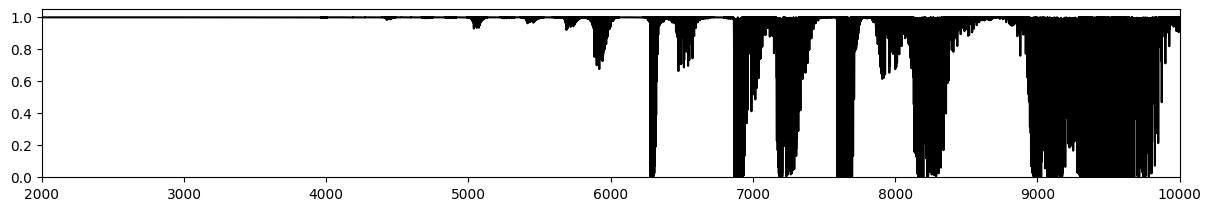

In [12]:
airmass = 1.5            # Airmass (>= 1.0)
humidity = 50            # Relative humidity
o2_abundance = 1000000   # in ppm

# Applies abundance + airmass information to models
tau_o2 = o2_model * o2_abundance * airmass
tau_h2o = humidity_model * humidity * airmass

# Combines models into a single array + handles bad values
tau_total = tau_o2 + tau_h2o
tau_total = np.nan_to_num(tau_total, nan=0.0, posinf=0.0, neginf=0.0)

# Plotting
plt.rcParams["figure.figsize"] = (12, 2)
plt.plot(model_wavelengths, np.exp(tau_total), color='k')
plt.xlim(2000, 10000)
plt.ylim(0, 1.05)

## Common Issues
### _Errors at High R_
The method used to approximate telluric extinction is far from perfect. However, these errors are typically less severe as spectral resolution drops. If you are working at a high spectral resolution and need a precise telluric throughput, you may have better luck using ```TelFit``` to generate your own model!

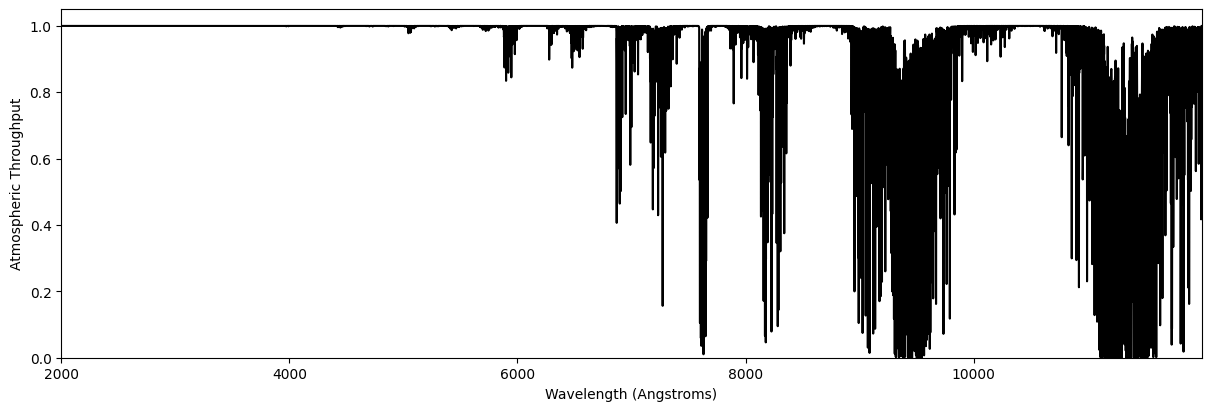

In [13]:
# Generates a telluric model at a very large R
really_high_R_model = ss.generate_extinction_model(
    wavelengths = wavelengths,
    o2_abundance = 10000,
    humidity = 10,
    R = 100000,
    airmass = 10.0,
)

# Plotting
plt.rcParams["figure.figsize"] = (12, 4)
plt.plot(wavelengths, really_high_R_model, color='k')
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Atmospheric Throughput")
plt.xlim(np.min(wavelengths.value), np.max(wavelengths.value))
plt.ylim(0, 1.05)
plt.show()

### _Invalid Wavelengths_

Since this tool was developed for KOSMOS data which only has sensitivity over red-visible to NIR wavelengths, the extinction models were only generated for (2000 $\AA$ < $\lambda$ < 10000 $\AA$). If you attempt to generate extinction models outside of this region, you will notice that the Rayleigh scattering losses break outside this range, and prominent molecular absorptions in the NIR are missing. If this is an issue for your reduction / analysis, please notify us so we can produce an updated set of models!

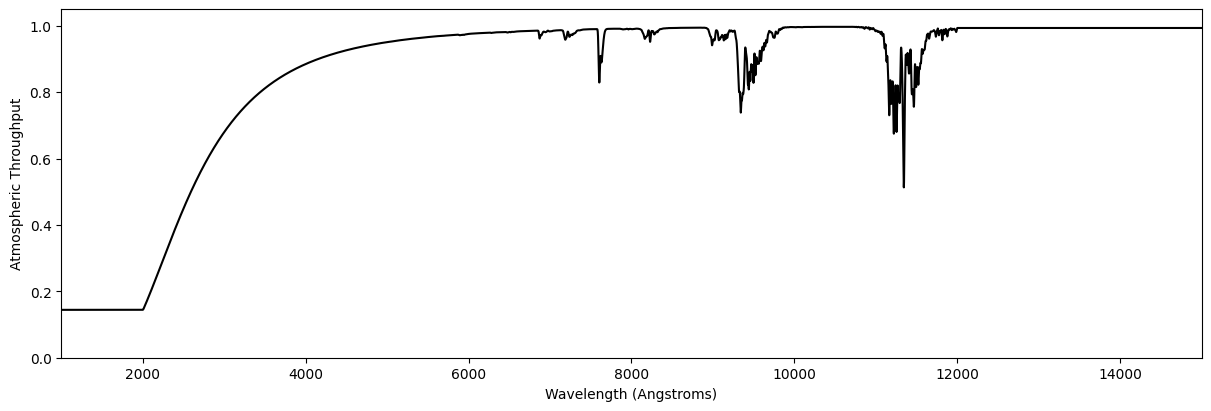

In [14]:
# Generates a model outside the recommended wavelengths
bad_wavelengths = np.arange(1000, 15000, 1)
bad_model = ss.generate_extinction_model(
    wavelengths = bad_wavelengths,
    rs_tau0 = 0.05,
    o2_abundance = 10000,
    humidity = 10,
    R = 1000,
)

# Plotting
plt.plot(bad_wavelengths, bad_model, color='k')
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Atmospheric Throughput")
plt.xlim(1000, 15000)
plt.ylim(0, 1.05)
plt.show()

### _Telluric Model Not Converging_
This is a tricky error to diagnose since ```estimate_atmospheric_loss()``` is doing a lot of complicated things under the hood. A good first check is often seeing what the debugging plots look like. Here is an example of what you should see produced...

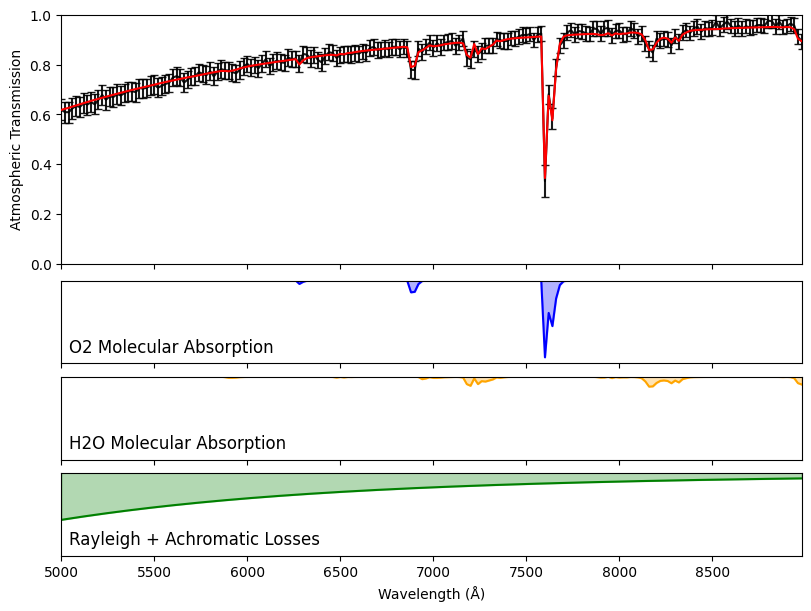

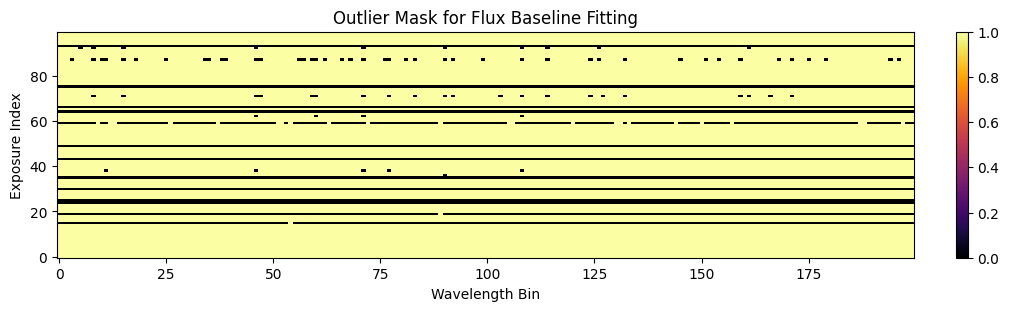

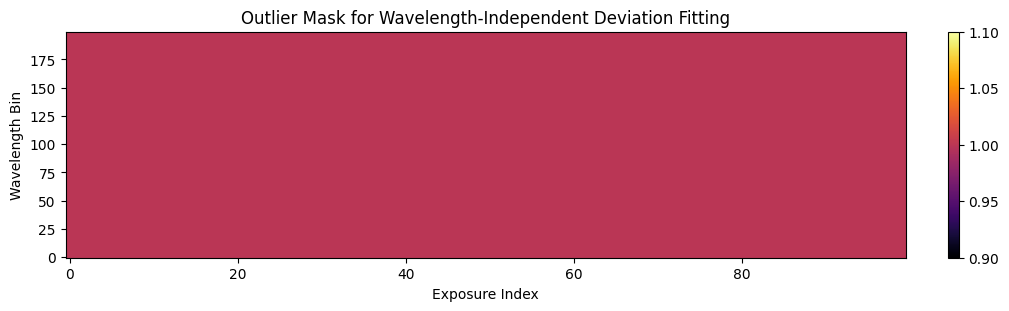

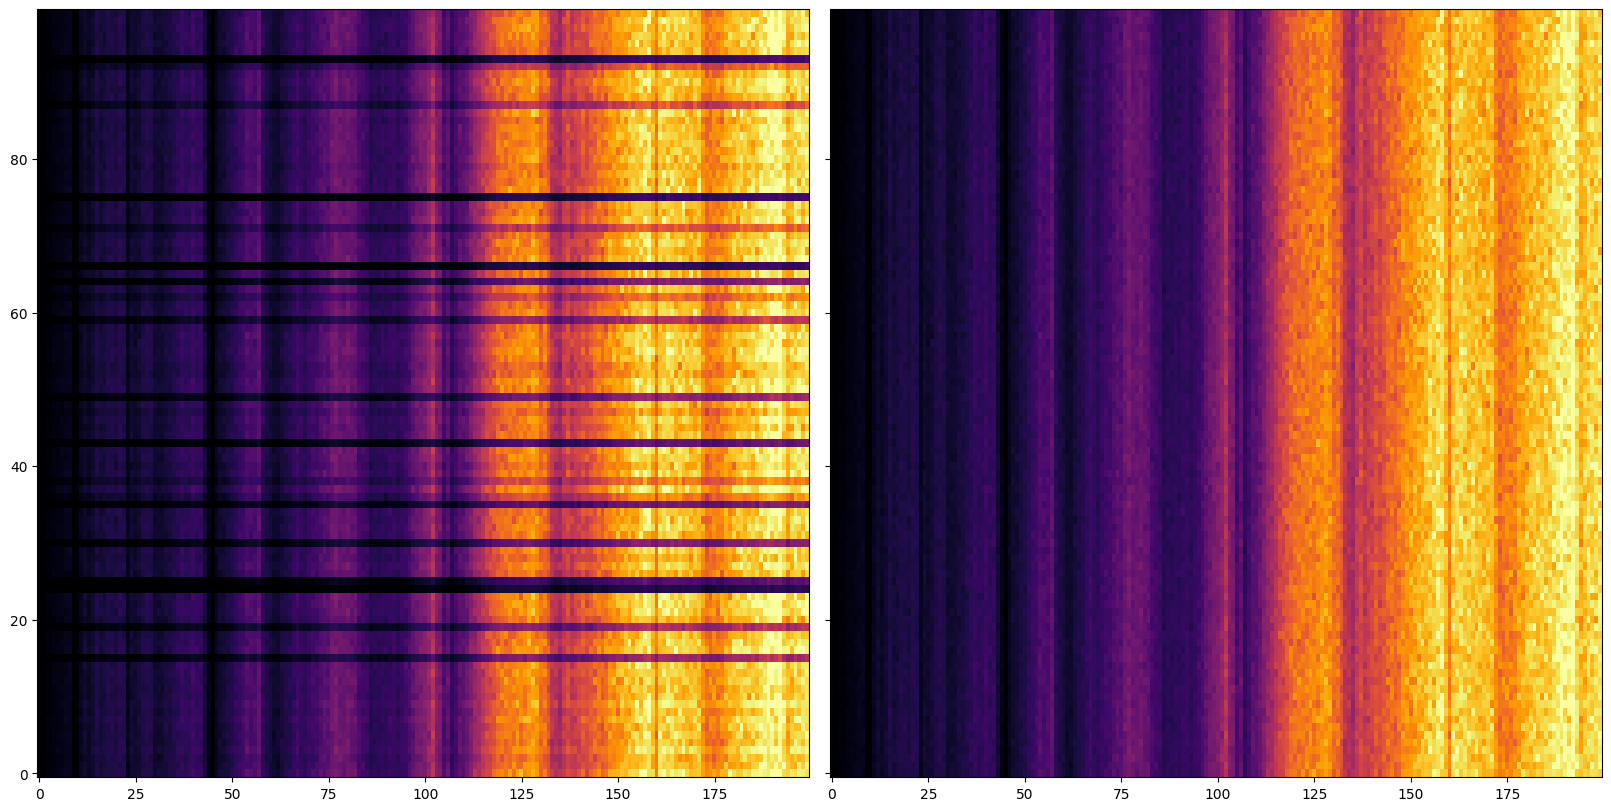

In [15]:
# Shows optional debugging plots for telluric models
correction = ss.estimate_atmospheric_loss(
    wavelengths = data_wavelengths,
    flux = data_flux_array,
    error = data_error_array,
    times = data_times,
    airmass = data_airmass,
    debug = True,
)

Let's unpack each step in ```estimate_atmospheric_loss()``` and discuss various points of failure...

__Atmospheric extinction coefficients should be negative__<br>
If is not the case, the fitting function will fail to converge to a reasonable answer. This problem comes from ```estimate_extinction_coefficients()``` which attempts to convert the flux as a function of airmass into an approximate extinction coefficient. This can happen if: (1) the sigma-clipping process flags too many (or too few) points as outliers, (2) the data is noisy and spans a low range of airmasses, or (3) cloud cover is so extreme that a night-averaged extinction coefficient is not easy to estimate. Try messing with the ```max_iterations``` and ```clip_threshold``` to see if some combination produces extinction coefficients less than zero.

<ErrorbarContainer object of 3 artists>

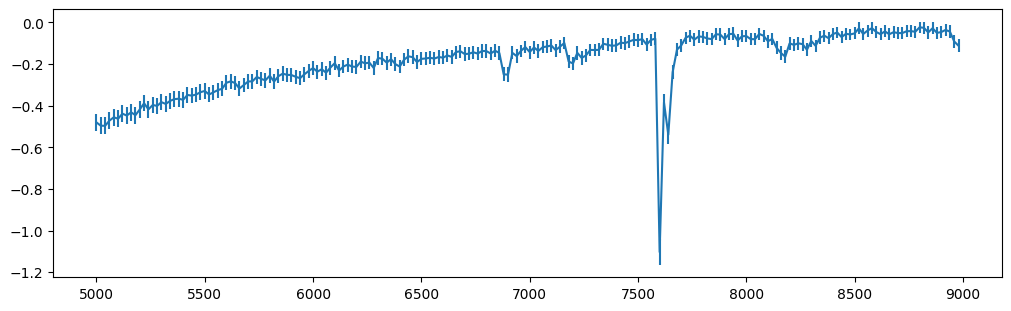

In [16]:
# Step 1: Estimate extinction coefficients (taus) for each wavelength bin
taus, taus_error = ss.estimate_extinction_coefficients(
    airmass = data_airmass,
    flux = data_flux_array,
    error = data_error_array,
    max_iterations = 5,
    clip_threshold = 5.0,
)

# Plots inferred extinction coefficients
plt.errorbar(data_wavelengths, taus, yerr = taus_error)

__Telluric transmission model should reasonably pass through data points__<br>
If the generated model is poor, this is caused by ```fit_extinction_model()```, which is attempting to describe the extinction coefficients extracted from your data in terms of Rayleigh scattering and molecular absorptions. If you think the issue lies in the initial guess or bounds, you can specify your own using the ```p0``` and ```bounds``` arguments (see docstring for help here). Otherwise, the issue is likely caused by: (1) extinction features present in your data are not included in the current model or (2) your instrument has non-telluric features that behave similarly to telluric extinction.

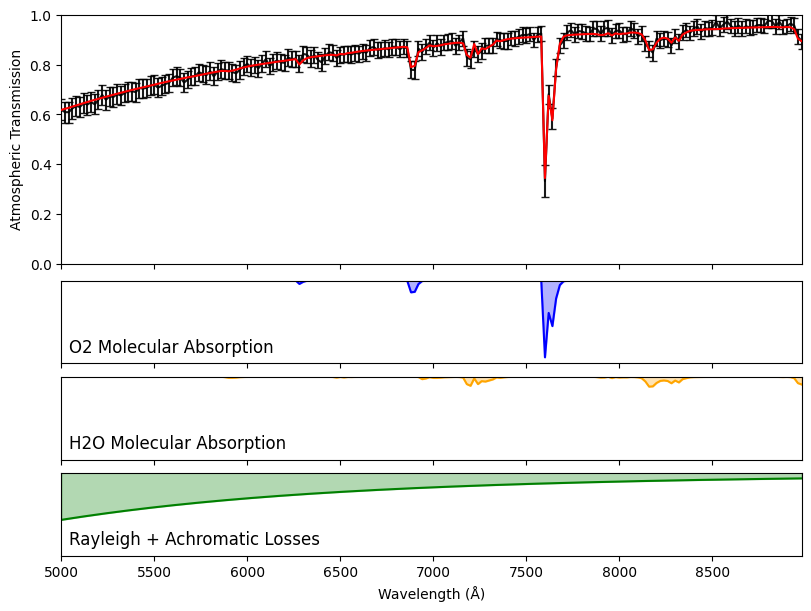

In [17]:
# Step 2: Fit the extinction model to the estimated taus
throughput_model, fitted_values, _ = ss.fit_extinction_model(
    wavelengths = data_wavelengths,
    taus = taus,
    taus_error = taus_error,
    debug = True,
)

__Flux baseline mask should mostly flag cloud cover__<br>
If the mask seems to be flagging something other than achromatic cloud coverage, this is caused by ```fit_achromatic_bumps()```. Ideally, the mask should have flat, horizontal lines corresponding to exposures where you see a significant drop in your observed flux. This is done by estimating the "baseline flux" of your target using a sloped line (to allow small amounts of stellar variability) and seeing how much each exposure deviates from that baseline. This can break down if: (1) your star has extreme variability that is poorly described by a straight line or (2) the sigma-clipping routine is flagging too many (or too few) points as outliers. Try messing with the ```max_iterations``` and ```clip_threshold``` to see if some combination produces a reasonable mask.

__Wavelength-independent mask should have nearly no masked values__<br>
If your mask has a significant number of flagged outliers, then ```fit_achromatic_bumps()``` may be struggling to understand spectral features in your dataset. Outliers are flagged by fitting a non-sloped line to each wavelength bin over time to infer how much light is lost across all wavelengths. The biggest issue with this assumption is that clouds can cause wavelength-dependent losses. Unfortunately, we do not have a method for handling these circumstances currently. You can try messing with the ```max_iterations``` and ```clip_threshold``` to see if some combination produces a reasonable mask, but it may be the case that certain exposure cannot be accurately corrected using ```specsuite```.

__The side-by-side plots should show your original and corrected datasets__<br>
Hopefully, if everything worked correctly, then the right exposure should look like a constant spectrum with some amount of noise. If not, then any of previous steps may have failed to model an aspect of telluric absorption present in your dataset. Assuming none of the previous checks / fixes worked for you, then ```specsuite``` probably cannot handle some features present in your data, sorry!

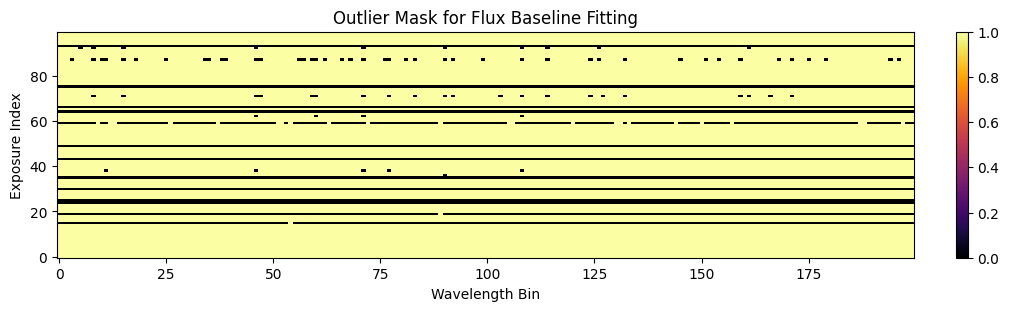

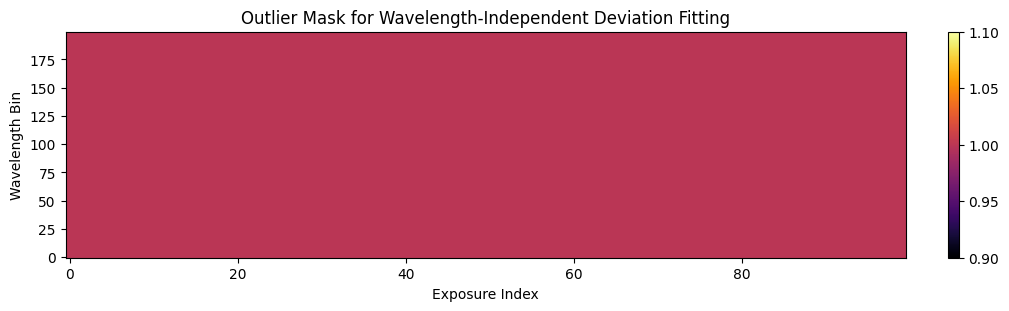

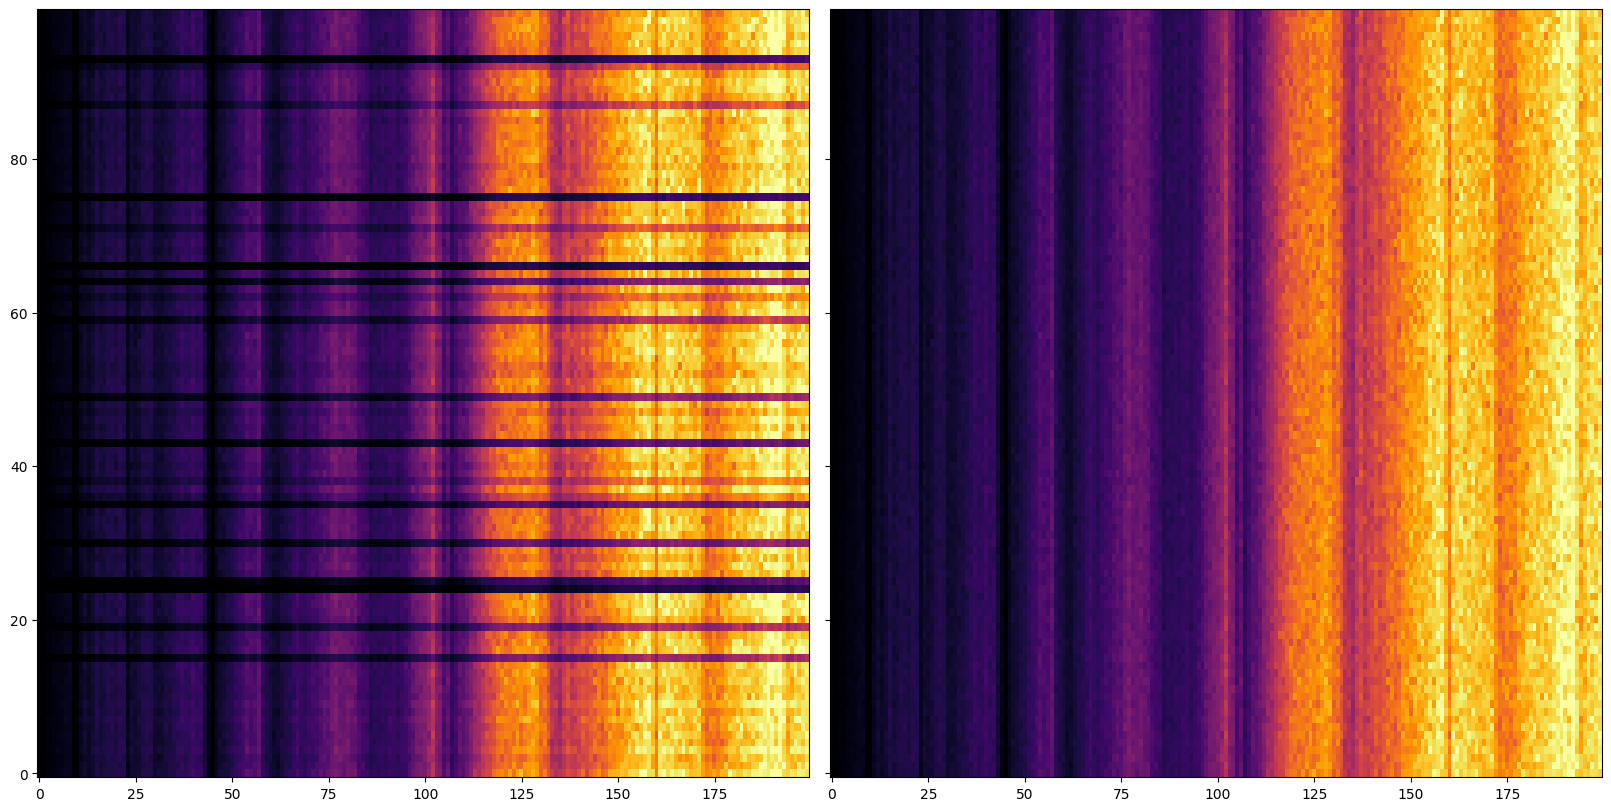

In [18]:
# Step 3: Calculate average telluric loss at each airmass
chromatic_correction = np.array([throughput_model(X) for X in data_airmass])

# Step 4: Fit achromatic bumps to the residuals after removing chromatic effects
achromatic_correction, _ = ss.fit_achromatic_bumps(
    times = data_times,
    flux = data_flux_array,
    error = data_error_array,
    airmasses = data_airmass,
    throughput_model = throughput_model,
    max_iterations = 5,
    outlier_threshold = 5.0,
    debug = True,
)